### Feb 2025: END SEMESTER ASSESSMENT  
### M.TECH DATA SCIENCE AND MACHINE LEARNING_ SEMESTER II

##	UE20CS931 - MACHINE LEARNING - II

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
from collections import Counter
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier, ExtraTreesClassifier, VotingClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, cross_val_score, StratifiedKFold, learning_curve, train_test_split, KFold
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from xgboost import XGBClassifier
from sklearn.model_selection import cross_val_score,KFold
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report,confusion_matrix
from sklearn.metrics import classification_report,confusion_matrix
from sklearn.model_selection import GridSearchCV
from imblearn.over_sampling import SMOTE
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings ('ignore')

sns.set(style='white', context='notebook', palette='deep')

ModuleNotFoundError: No module named 'xgboost'

## Data description

This dataset contains information about employees in a company, including their educational backgrounds, work history, demographics, and employment-related factors. It has been anonymized to protect privacy while still providing valuable insights into the workforce.

Columns:

Education: The educational qualifications of employees, including degree, institution, and field of study.

Joining Year: The year each employee joined the company, indicating their length of service.

City: The location or city where each employee is based or works.

Payment Tier: Categorization of employees into different salary tiers.

Age: The age of each employee, providing demographic insights.

Gender: Gender identity of employees, promoting diversity analysis.

Ever Benched: Indicates if an employee has ever been temporarily without assigned work.

Experience in Current Domain: The number of years of experience employees have in their current field.

WorkHoursPerWeek: Work hours per week of the employee

AnnualBonus :  Annual gross bonus.

Leave or Not: a target column



In [5]:
df = pd.read_csv("dataset1.csv")
df.head()

,Education,JoiningYear,City,PaymentTier,Age,Gender,EverBenched,ExperienceInCurrentDomain,LeaveOrNot,WorkHoursPerWeek,AnnualBonus
0,Bachelors,2017,Bangalore,3,34.0,Male,No,0,0,41.236204,17736.470299
1,Bachelors,2013,Pune,1,28.0,Female,No,3,1,58.521429,10750.957116
2,Bachelors,2014,New Delhi,3,38.0,Female,No,2,0,51.959818,7524.178828
3,Masters,2016,Bangalore,3,27.0,Male,No,5,1,47.959755,17546.632887
4,Masters,2017,Pune,3,24.0,Male,Yes,2,1,34.680559,13233.644475


### 2(a).  Read the dataset and print the following (8 marks)
     (i) Describe the structure of a given dataset in terms of its shape, the number of numerical and categorical variables, and provide descriptive statistics for both types of variables. Additionally, mention any key observations based on the descriptive statistics. (5 mark)
      (ii) Summarize the categorical variables in a dataset by identifying the number of unique categories and the proportion of observations in each category. Highlight any noticeable patterns or anomalies. (3 mark)


In [8]:
# 2)A)i) Describe the structure of a given dataset in terms of its shape.
print('\nsturcture of the data set:')
print('Rows =',df.shape[0])
print('columns:',df.shape[1])


sturcture of the data set:
Rows = 4653
columns: 11


In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4653 entries, 0 to 4652
Data columns (total 11 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Education                  4653 non-null   object 
 1   JoiningYear                4653 non-null   int64  
 2   City                       4653 non-null   object 
 3   PaymentTier                4653 non-null   int64  
 4   Age                        4420 non-null   float64
 5   Gender                     4653 non-null   object 
 6   EverBenched                4606 non-null   object 
 7   ExperienceInCurrentDomain  4653 non-null   int64  
 8   LeaveOrNot                 4653 non-null   int64  
 9   WorkHoursPerWeek           4653 non-null   float64
 10  AnnualBonus                4653 non-null   float64
dtypes: float64(3), int64(4), object(4)
memory usage: 400.0+ KB


In [27]:
# 2)A)i) The number of numerical and categorical variables.
num_cols=df.select_dtypes(include='number').columns
print(f'Numerical columns:{list(num_cols)}')

cat_cols=df.select_dtypes(include='object').columns
print(f'Categorical columns:{list(cat_cols)}')

Numerical columns:['JoiningYear', 'PaymentTier', 'Age', 'ExperienceInCurrentDomain', 'LeaveOrNot', 'WorkHoursPerWeek', 'AnnualBonus']
Categorical columns:['Education', 'City', 'Gender', 'EverBenched']


In [21]:
#2)A)i) Descriptive statistics for both types of variables.
df.describe(include='number').T


,count,mean,std,min,25%,50%,75%,max
Education,4653.0,0.264560,0.521120,0.000000,0.000000,0.000000,0.000000,2.000000
JoiningYear,4653.0,2015.062970,1.863377,2012.000000,2013.000000,2015.000000,2017.000000,2018.000000
City,4653.0,0.793681,0.841979,0.000000,0.000000,1.000000,2.000000,2.000000
PaymentTier,4653.0,2.698259,0.561435,1.000000,3.000000,3.000000,3.000000,3.000000
Age,4420.0,29.403394,4.834246,22.000000,26.000000,28.000000,32.000000,41.000000
Gender,4653.0,0.597034,0.490547,0.000000,0.000000,1.000000,1.000000,1.000000
EverBenched,4653.0,0.120997,0.355789,0.000000,0.000000,0.000000,0.000000,2.000000
ExperienceInCurrentDomain,4653.0,2.905652,1.558240,0.000000,2.000000,3.000000,4.000000,7.000000
LeaveOrNot,4653.0,0.343864,0.475047,0.000000,0.000000,0.000000,1.000000,1.000000
WorkHoursPerWeek,4653.0,44.913360,8.681555,30.000349,37.360569,45.045489,52.394742,59.991530


In [28]:
df.describe(include='object').T

,count,unique,top,freq
Education,4653,3,Bachelors,3601
City,4653,3,Bangalore,2228
Gender,4653,2,Male,2778
EverBenched,4606,2,No,4137


In [2]:
# Key observations
#The average age of employees is 29.4 years.
#The average working hours per week are 44.9 hours.
#The average annual bonus is approximately 12,376.
#Most employees joined between 2012 and 2018.
#The Age column contains missing values (4420 values instead of 4653).

In [29]:
#2)A)ii)Summarize the categorical variables in a dataset by identifying the number of unique categories and the proportion of observations in each category.
print('\n NO of categorical varibles:')
print( df[cat_cols].nunique())

print('\n percentage of observation:')
print((df[cat_cols].value_counts(normalize=True)*100).round(2))



 NO of categorical varibles:
Education      3
City           3
Gender         2
EverBenched    2
dtype: int64

 percentage of observation:
Education  City       Gender  EverBenched
Bachelors  Bangalore  Male    No             27.46
                      Female  No             11.68
           Pune       Male    No             10.05
                      Female  No              9.25
           New Delhi  Female  No              6.80
Masters    New Delhi  Male    No              5.69
                      Female  No              4.26
Bachelors  Bangalore  Male    Yes             3.91
           New Delhi  Male    No              3.76
Masters    Pune       Male    No              2.61
                      Female  No              2.06
           Bangalore  Male    No              1.39
Bachelors  Pune       Male    Yes             1.28
                      Female  Yes             1.24
PHD        New Delhi  Male    No              1.24
Masters    Bangalore  Female  No              1.04
Ba

#Education
#Category	Percentage
#Bachelors	77.39%
#Masters	18.76%
#PHD	3.85%

#Observation: Most employees have a Bachelor's degree.

#City
#Category	Percentage
#Bangalore	47.88%
#Pune	27.25%
#New Delhi	24.87%

#Observation: Bangalore has the highest number of employees.

#Gender
#Category	Percentage
#Male	59.70%
#Female	40.30%

#Observation: Male employees are more than female employees.

#EverBenched
#Category	Percentage
#No	88.91%
#Yes	10.08%
#Missing	1.01%

#Observation: Most employees were never benched, and there are a few missing values.

### 2 (b). Examine missing values, outliers by plotting . Examine is the Target variable evenly balanced. (8 Marks)

                           Missing Values  percentage
Education                               0        0.00
JoiningYear                             0        0.00
City                                    0        0.00
PaymentTier                             0        0.00
Age                                   233        5.01
Gender                                  0        0.00
EverBenched                            47        1.01
ExperienceInCurrentDomain               0        0.00
LeaveOrNot                              0        0.00
WorkHoursPerWeek                        0        0.00
AnnualBonus                             0        0.00


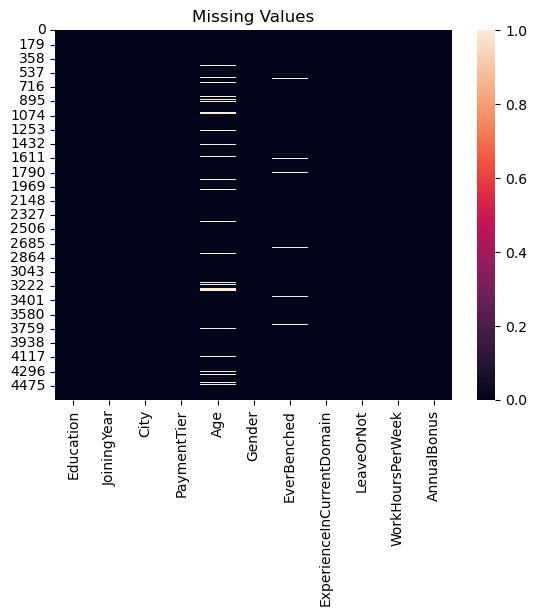

In [30]:
# 2)B)i)Examine missing values.
missing_vlaues=pd.DataFrame({'Missing Values':df.isnull().sum(),'percentage':((df.isnull().sum()/len(df))*100).round(2)})
print(missing_vlaues)
sns.heatmap(df.isnull())
plt.title('Missing Values')
plt.show()

PaymentTier:1161 outliers


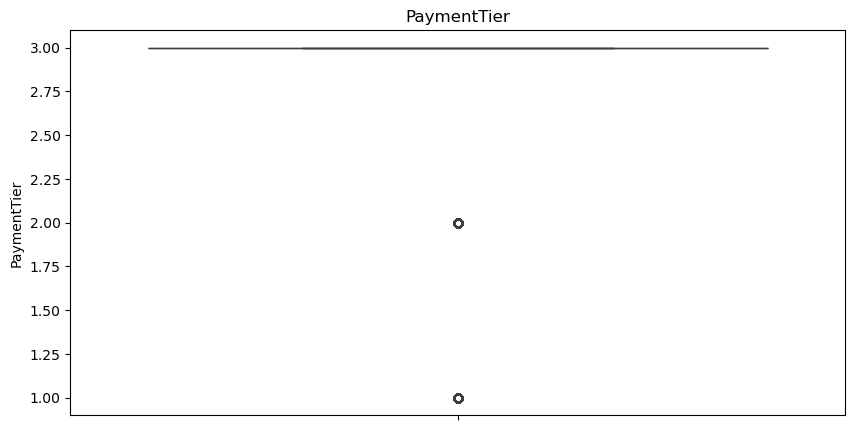

In [31]:
#2)B)ii) Outliers by plotting.
num_cols=df.select_dtypes(include='number').columns
for col in num_cols:
    Q1,Q3=df[col].quantile(0.25),df[col].quantile(0.75)
    IQR=Q3-Q1
    outliers=((df[col]<Q1-1.5*IQR)|(df[col]>Q3+1.5*IQR)).sum()
    if outliers>0:
        print(f'{col}:{outliers} outliers')
        plt.figure(figsize=(10,5))
        sns.boxplot(data=df[col])
        plt.xticks(rotation=90)
        plt.title(col)
        plt.show()
        

LeaveOrNot
0    65.613583
1    34.386417
Name: proportion, dtype: float64


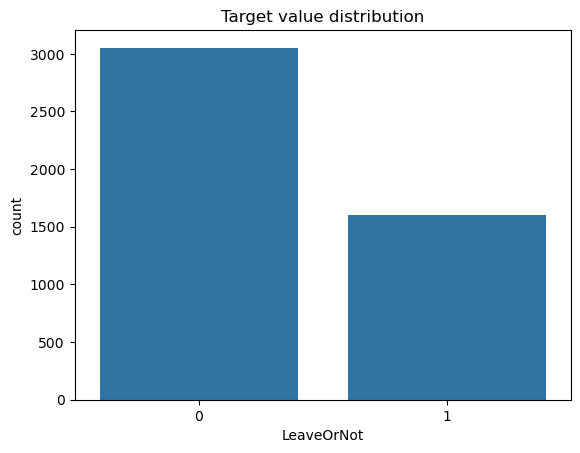

In [32]:
#2)B)iii) Examine is the Target variable evenly balanced.
print(df['LeaveOrNot'].value_counts(normalize=True)*100)
sns.countplot(x='LeaveOrNot',data=df)
plt.title('Target value distribution')
plt.show()

### 2 (c).Perform appropriate encoding on the categorical attributes. (6 Marks)

In [33]:
#2)C)Perform appropriate encoding.
cat_cols=df.select_dtypes(include='object').columns
df_encoded=pd.get_dummies(df,columns=cat_cols,drop_first=True,dtype=int)
print(df_encoded.head())

   JoiningYear  PaymentTier   Age  ExperienceInCurrentDomain  LeaveOrNot  \
0         2017            3  34.0                          0           0   
1         2013            1  28.0                          3           1   
2         2014            3  38.0                          2           0   
3         2016            3  27.0                          5           1   
4         2017            3  24.0                          2           1   

   WorkHoursPerWeek   AnnualBonus  Education_Masters  Education_PHD  \
0         41.236204  17736.470299                  0              0   
1         58.521429  10750.957116                  0              0   
2         51.959818   7524.178828                  0              0   
3         47.959755  17546.632887                  1              0   
4         34.680559  13233.644475                  1              0   

   City_New Delhi  City_Pune  Gender_Male  EverBenched_Yes  
0               0          0            1              

### 2(d) Perform necessary actions to ‘fix’  defects in the data  (8 marks)
(i) Impute the missing values using central values (Mean, median, mode)

(ii) Detect the outliers and decide if any treatment is required.

(iii) Detect the unnecessary features and remove.

Education                    0
JoiningYear                  0
City                         0
PaymentTier                  0
Age                          0
Gender                       0
EverBenched                  0
ExperienceInCurrentDomain    0
LeaveOrNot                   0
WorkHoursPerWeek             0
AnnualBonus                  0
dtype: int64


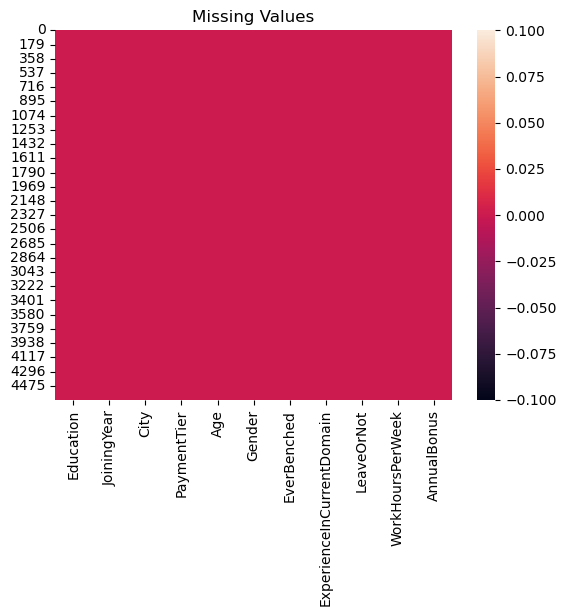

In [45]:
# 2)D)i)Impute the missing values using central values
df['Age']=df['Age'].fillna(df['Age'].median())
df['EverBenched']=df['EverBenched'].fillna(df['EverBenched'].mode()[0])
print(df.isnull().sum())
sns.heatmap(df.isnull())
plt.title('Missing Values')
plt.show()

PaymentTier:1161 outliers
JoiningYear:0 outliers


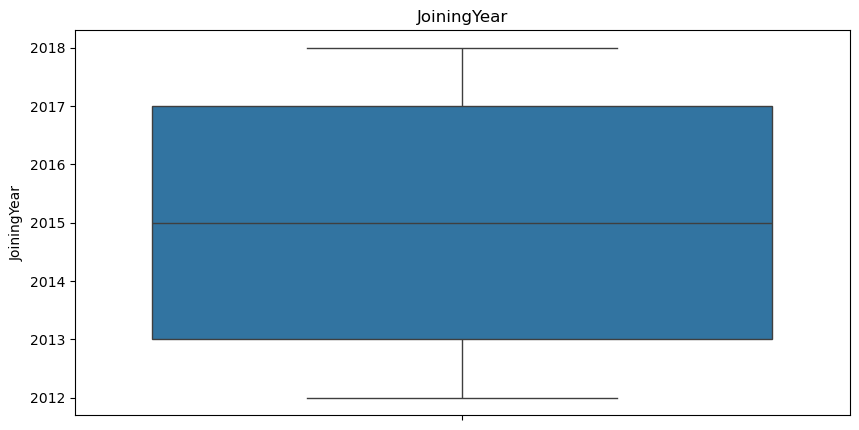

PaymentTier:0 outliers


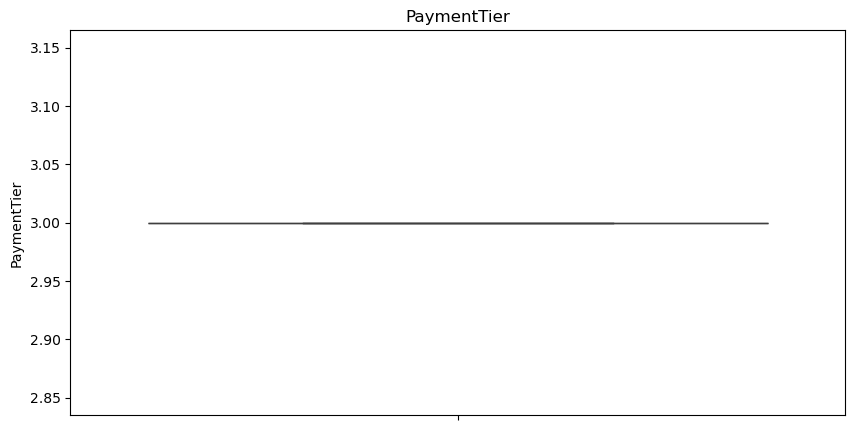

Age:0 outliers


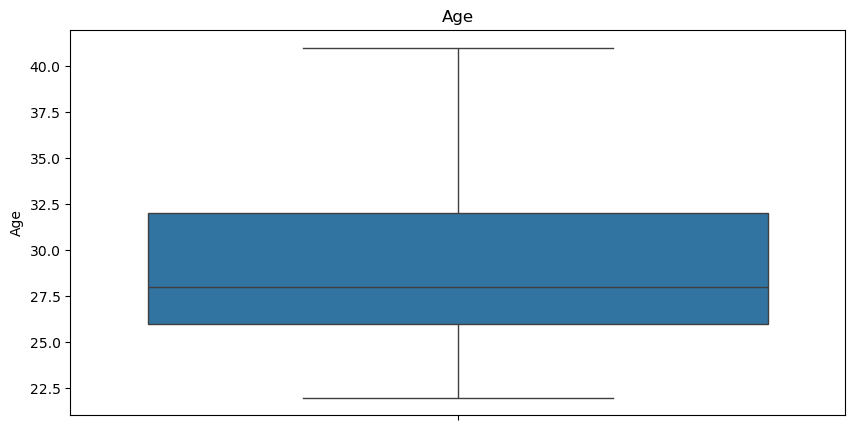

ExperienceInCurrentDomain:0 outliers


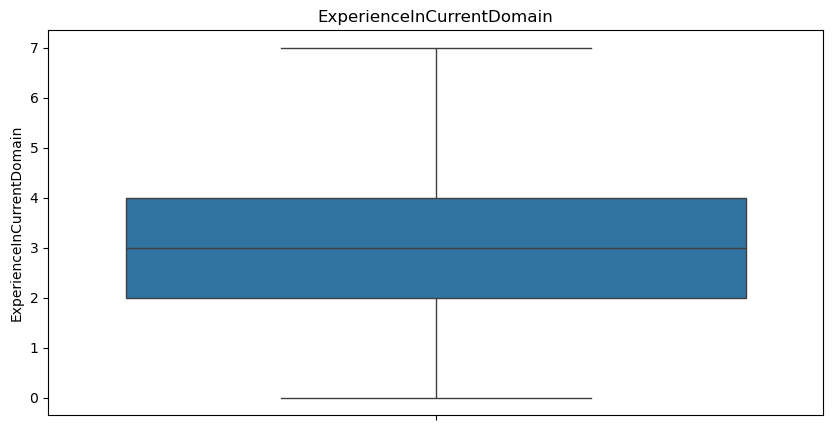

LeaveOrNot:0 outliers


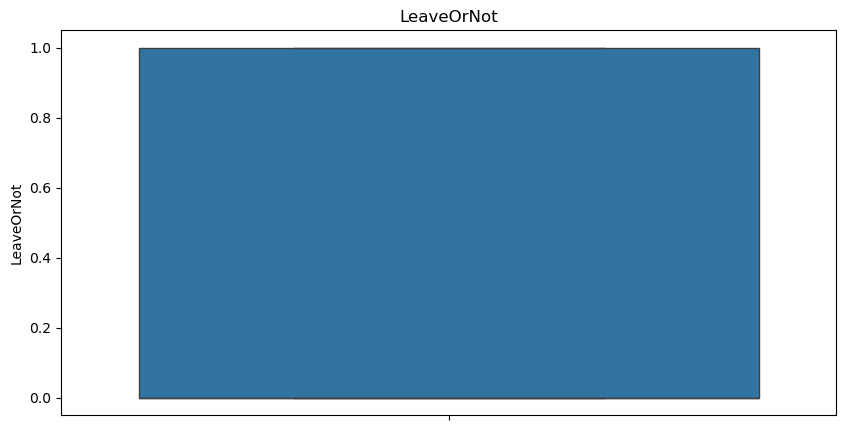

WorkHoursPerWeek:0 outliers


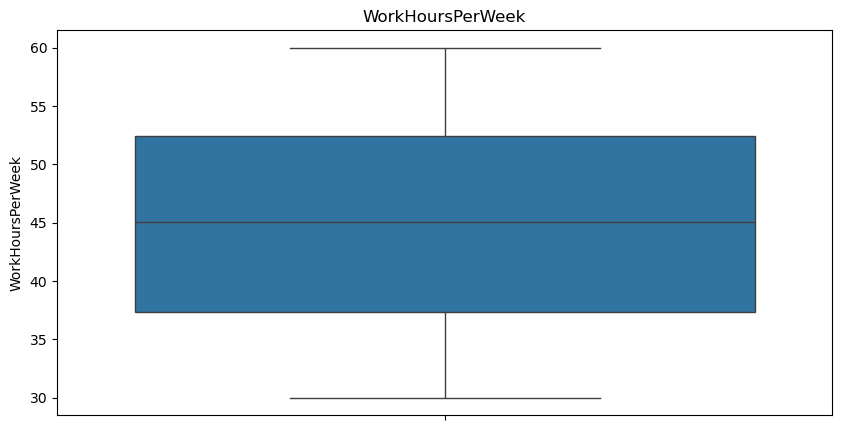

AnnualBonus:0 outliers


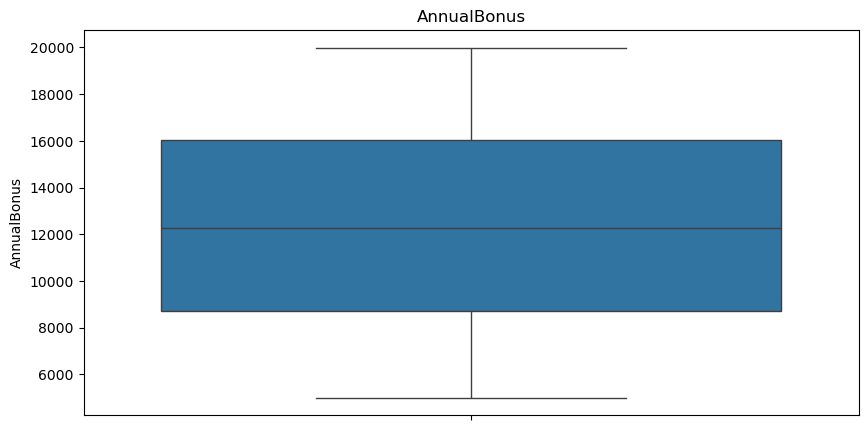

In [35]:
# 2)D)ii) Detect the outliers and decide if any treatment is required.
num_cols=df.select_dtypes(include='number').columns
for col in num_cols:
    Q1,Q3=df[col].quantile(0.25),df[col].quantile(0.75)
    IQR=Q3-Q1
    outliers=((df[col]<Q1-1.5*IQR)|(df[col]>Q3+1.5*IQR)).sum()
    if outliers>0:
        print(f'{col}:{outliers} outliers')
num_cols=df.select_dtypes(include='number').columns
for col in num_cols:
    Q1,Q3=df[col].quantile(0.25),df[col].quantile(0.75)
    IQR=Q3-Q1
    lower=Q1-1.5*IQR
    upper=Q3+1.5*IQR
    df[col]=df[col].clip(lower,upper)
    print(f'{col}:{outliers} outliers')
    plt.figure(figsize=(10,5))
    sns.boxplot(data=df[col])
    plt.xticks(rotation=90)
    plt.title(col)
    plt.show()

                           JoiningYear  PaymentTier       Age  \
JoiningYear                   1.000000          NaN  0.013765   
PaymentTier                        NaN          NaN       NaN   
Age                           0.013765          NaN  1.000000   
ExperienceInCurrentDomain    -0.036525          NaN -0.129221   
LeaveOrNot                    0.181705          NaN -0.045905   
WorkHoursPerWeek             -0.026055          NaN  0.002095   
AnnualBonus                   0.004494          NaN -0.005340   

                           ExperienceInCurrentDomain  LeaveOrNot  \
JoiningYear                                -0.036525    0.181705   
PaymentTier                                      NaN         NaN   
Age                                        -0.129221   -0.045905   
ExperienceInCurrentDomain                   1.000000   -0.030504   
LeaveOrNot                                 -0.030504    1.000000   
WorkHoursPerWeek                            0.016636    0.002223   
Ann

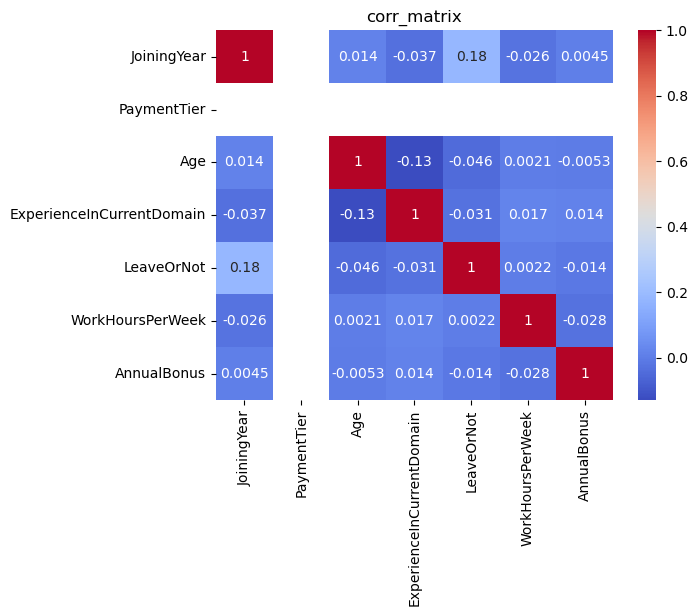

In [36]:
# 2)D)iii) Detect the unnecessary features and remove.
corr_matrix=df[num_cols].corr()
print(corr_matrix)
sns.heatmap(corr_matrix,annot=True,cmap='coolwarm')
plt.title('corr_matrix')
plt.show()

### 2(e). Examine the correlation and summarize the relationship between variables. Use appropriate plots to justify the same. (6 marks)               

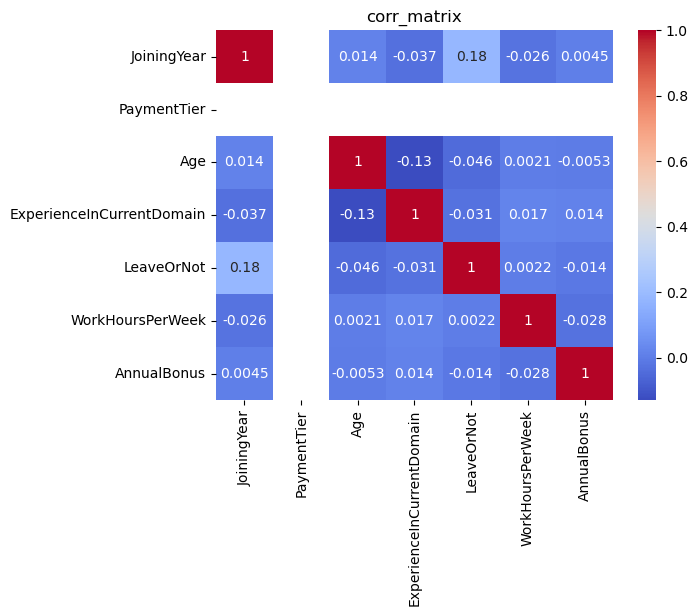

<Figure size 1200x800 with 0 Axes>

In [37]:
# 2)E)i)Examine the correlation and summarize the relationship between variables.
sns.heatmap(corr_matrix,annot=True,cmap='coolwarm')
plt.title('corr_matrix')
plt.figure(figsize=(12,8))
plt.show()

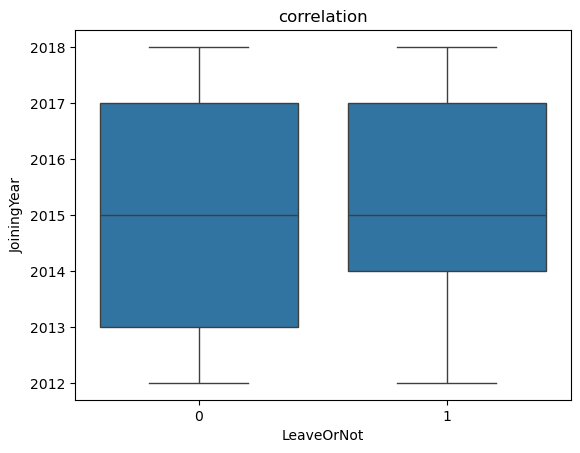

<Figure size 1000x500 with 0 Axes>

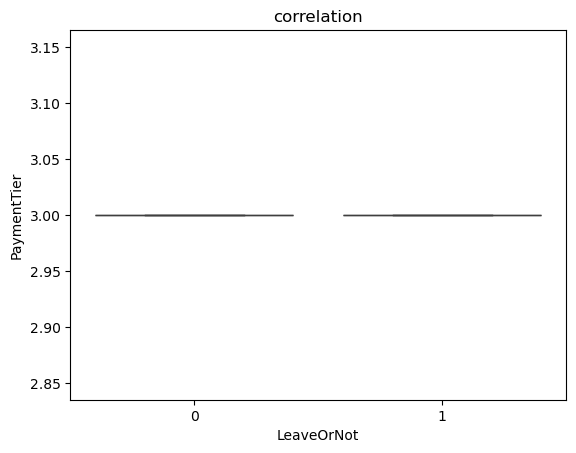

<Figure size 1000x500 with 0 Axes>

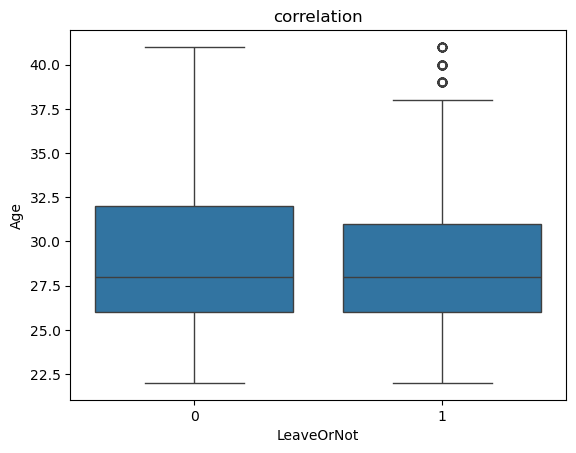

<Figure size 1000x500 with 0 Axes>

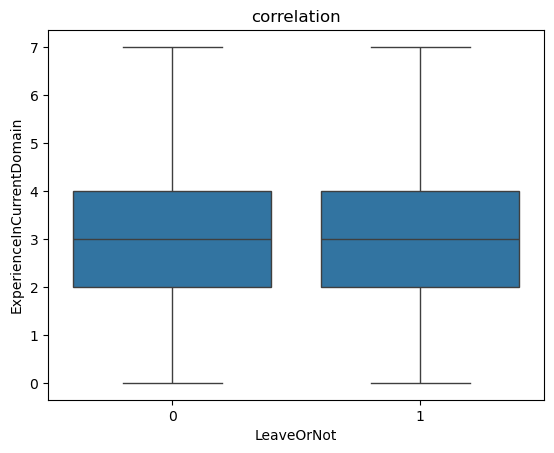

<Figure size 1000x500 with 0 Axes>

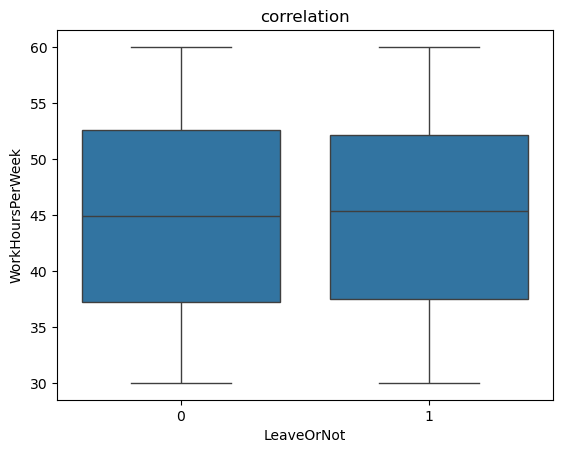

<Figure size 1000x500 with 0 Axes>

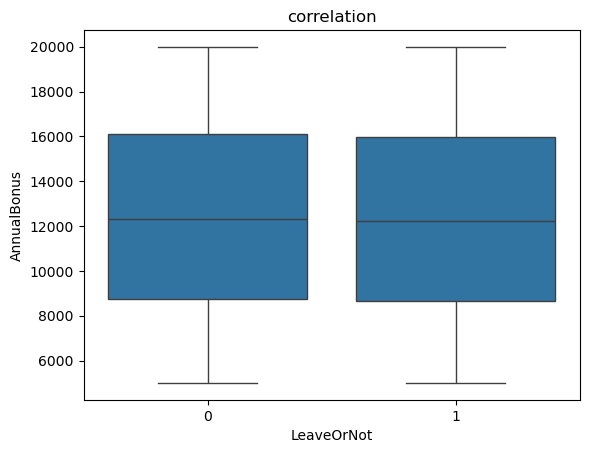

<Figure size 1000x500 with 0 Axes>

In [38]:
# 2)E)ii)Examine the correlation and summarize the relationship between variables.
num_cols=['JoiningYear', 'PaymentTier', 'Age', 'ExperienceInCurrentDomain', 'WorkHoursPerWeek', 'AnnualBonus']
for col in num_cols:
    sns.boxplot(x='LeaveOrNot',y=col,data=df)
    plt.title('correlation')
    plt.figure(figsize=(10,5))
    plt.show()

### 2(f). Split dataset into train and test (70:30)  (4 marks)   

In [46]:
# 2)F) Split dataset into train and test.
X=df.drop('LeaveOrNot',axis=1)
y=df['LeaveOrNot']
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.30,random_state=42)
print(X_test.shape)
print(X_train.shape)
print(y_train.shape)
print(y_test.shape)

(1396, 10)
(3257, 10)
(3257,)
(1396,)


In [47]:
## LABEL ENCODER
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
cat_cols=df.select_dtypes(include='object').columns
for col in cat_cols:
    df[col]=le.fit_transform(df[col])
print(df.head())    

   Education  JoiningYear  City  PaymentTier   Age  Gender  EverBenched  \
0          0         2017     0            3  34.0       1            0   
1          0         2013     2            3  28.0       0            0   
2          0         2014     1            3  38.0       0            0   
3          1         2016     0            3  27.0       1            0   
4          1         2017     2            3  24.0       1            1   

   ExperienceInCurrentDomain  LeaveOrNot  WorkHoursPerWeek   AnnualBonus  
0                          0           0         41.236204  17736.470299  
1                          3           1         58.521429  10750.957116  
2                          2           0         51.959818   7524.178828  
3                          5           1         47.959755  17546.632887  
4                          2           1         34.680559  13233.644475  


In [48]:
df.isnull().sum()

Education                    0
JoiningYear                  0
City                         0
PaymentTier                  0
Age                          0
Gender                       0
EverBenched                  0
ExperienceInCurrentDomain    0
LeaveOrNot                   0
WorkHoursPerWeek             0
AnnualBonus                  0
dtype: int64

In [49]:
df.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
4648    False
4649    False
4650    False
4651    False
4652    False
Length: 4653, dtype: bool

In [41]:
## BALANCE THE DATA SET.
from imblearn.over_sampling import SMOTE
X=df.drop('LeaveOrNot',axis=1)
y=df['LeaveOrNot']
smote = SMOTE(random_state=42)
X_resampled,y_resampled=smote.fit_resample(X,y)
print(y_resampled.value_counts())


LeaveOrNot
0    3053
1    3053
Name: count, dtype: int64


### Section C (30 marks)

### 3 (a) Fit a Logistic Regression model and compare the results with respect to different threshold values. Please write your key observations based on F1 score for your model. (16 marks)

In [50]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score
model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

y_prob = model.predict_proba(X_test)[:,1]

thresholds = [0.3,0.4,0.5,0.6,0.7]

for t in thresholds:

    y_pred = (y_prob >= t).astype(int)

    f1 = f1_score(y_test, y_pred)

    print("Threshold =", t)

    print("F1 Score =", round(f1,3))

    print()

Threshold = 0.3
F1 Score = 0.533

Threshold = 0.4
F1 Score = 0.542

Threshold = 0.5
F1 Score = 0.488

Threshold = 0.6
F1 Score = 0.152

Threshold = 0.7
F1 Score = 0.045



C:\Users\ramj0\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


### 3 (b) Compare the performance of Logistic regression, Decision Tree and Random Forest on the given dataset. Analyze the results, clearly state the changes or optimizations you would make to each model before re-fitting, and justify your approach.  (16 Marks)

In [51]:
# Logistic Regression

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

print("Logistic Regression")

print("Accuracy =", accuracy_score(y_test, lr_pred))

print("F1 Score =", f1_score(y_test, lr_pred))


# Decision Tree

dt = DecisionTreeClassifier()

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

print("\nDecision Tree")

print("Accuracy =", accuracy_score(y_test, dt_pred))

print("F1 Score =", f1_score(y_test, dt_pred))


# Random Forest

rf = RandomForestClassifier()

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

print("\nRandom Forest")

print("Accuracy =", accuracy_score(y_test, rf_pred))

print("F1 Score =", f1_score(y_test, rf_pred))

C:\Users\ramj0\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic Regression
Accuracy = 0.7234957020057307
F1 Score = 0.4880636604774536

Decision Tree
Accuracy = 0.752865329512894
F1 Score = 0.6379853095487933

Random Forest
Accuracy = 0.8459885386819485
F1 Score = 0.7329192546583851


### 3 (c) Summarize the solution to the business problem as follows (8 marks):

* Feature Importance (4 marks): Identify and explain which features are most influential in solving the problem and why.

* Evaluation Metrics Performance (2 marks)Provide an analysis of the model's performance based on key evaluation metrics.

* Overall Results and Observations (2 marks): Summarize the overall findings, including key insights and their implications for the business problem.
